# 1. Setup

### 1.1 Install deps & packages

In [14]:
%pip install numpy pandas matplotlib kagglehub
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import kagglehub
import shutil
import os

You should consider upgrading via the '/Users/Hita/Desktop/Transaction-fraud-detection/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


### 1.2 Download dataset

In [15]:
try:
    os.mkdir('original_dataset')
    kagglehub.dataset_download("zahranusratt/banking-fraud-detection-dataset", output_dir='original_dataset')
except FileExistsError:
    pass

# Remove uesless metadata
shutil.rmtree('original_dataset/.complete/', ignore_errors=True)

print('Dataset downloaded')

Dataset downloaded


# 2. Data pipeline

### 2.1 Load csv into dataframe

In [16]:
fraud_data = pd.read_csv('original_dataset/FraudShield_Banking_Data (1).csv')

print(f"Shape\n{fraud_data.shape}\n")
print(f"Head\n{fraud_data.head()}")
print("\nColumns")
for column_number, column_name in enumerate(fraud_data.columns, start=1):
    print(column_number, column_name)

Shape
(50000, 25)

Head
   Transaction_ID  Customer_ID  Transaction_Amount (in Million)  \
0        431438.0      24239.0                              6.0   
1        902451.0      77250.0                              9.0   
2        223410.0      34294.0                              3.0   
3        145626.0      92041.0                              1.0   
4        414637.0      71578.0                              1.0   

  Transaction_Time Transaction_Date Transaction_Type  Merchant_ID  \
0            10:54       2025-03-08              POS      97028.0   
1            19:23       2025-01-17              ATM      27515.0   
2            10:20       2025-04-30              POS      13810.0   
3            14:11       2025-02-21           Online      10501.0   
4            04:12       2025-04-11           Online      53569.0   

  Merchant_Category Transaction_Location Customer_Home_Location  ...  \
0               ATM            Singapore                 Lahore  ...   
1             

In [17]:
fraud_data_original = fraud_data.copy(deep=True)

print("Records:", fraud_data_original.shape[0])
print("Columns:", fraud_data_original.shape[1])

print("\nData-type counts:")
print(fraud_data_original.dtypes.value_counts())

Records: 50000
Columns: 25

Data-type counts:
float64    13
object     12
Name: count, dtype: int64


In [18]:
summary = pd.DataFrame({
    'dtype': fraud_data_original.dtypes,
    'sample_values': [fraud_data_original[col].dropna().unique()[:3] for col in fraud_data_original.columns]
})
print(summary.to_string())

                                         dtype                                  sample_values
Transaction_ID                         float64                 [431438.0, 902451.0, 223410.0]
Customer_ID                            float64                    [24239.0, 77250.0, 34294.0]
Transaction_Amount (in Million)        float64                                [6.0, 9.0, 3.0]
Transaction_Time                        object                          [10:54, 19:23, 10:20]
Transaction_Date                        object           [2025-03-08, 2025-01-17, 2025-04-30]
Transaction_Type                        object                             [POS, ATM, Online]
Merchant_ID                            float64                    [97028.0, 27515.0, 13810.0]
Merchant_Category                       object                    [ATM, Electronics, Grocery]
Transaction_Location                    object                [Singapore, Faisalabad, London]
Customer_Home_Location                  object              

2.  Numeric ranges, missing values, duplicates, and inconsistent entries

In [19]:


print("\n" + "="*60)
print("NUMERIC RANGES")
print("="*60)
print(fraud_data_original.describe())

print("\n" + "="*60)
print("CATEGORICAL SUMMARY")
print("="*60)
print(fraud_data_original.describe(include='object'))

print("\n" + "="*60)
print("UNIQUE VALUES (categorical columns)")
print("="*60)
for col in fraud_data_original.select_dtypes(include="object").columns:
    print(f"\n{col}: {fraud_data_original[col].nunique()} unique values")
    print(fraud_data_original[col].unique()[:15])

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
missing = fraud_data_original.isna().sum()
missing_pct = (missing / len(fraud_data_original) * 100).round(2)
missing_summary = pd.DataFrame({"missing": missing, "pct": missing_pct})
print(missing_summary[missing_summary["missing"] > 0].sort_values("missing", ascending=False))

print("\n" + "="*60)
print("DUPLICATE ROWS")
print("="*60)
print("Full duplicate rows:", fraud_data_original.duplicated().sum())
if "transaction_id" in fraud_data_original.columns:
    print("Duplicate transaction_id:", fraud_data_original["transaction_id"].duplicated().sum())


NUMERIC RANGES
       Transaction_ID   Customer_ID  Transaction_Amount (in Million)  \
count    49997.000000  49990.000000                     49991.000000   
mean    550400.968898  54869.720744                         4.999880   
std     259677.602349  26052.824933                         2.582025   
min     100043.000000  10005.000000                         1.000000   
25%     324445.000000  32259.250000                         3.000000   
50%     552115.000000  54720.500000                         5.000000   
75%     775942.000000  77542.000000                         7.000000   
max     999992.000000  99996.000000                         9.000000   

        Merchant_ID  Distance_From_Home      Device_ID  \
count  49993.000000        49998.000000   49991.000000   
mean   54951.375913          300.098564  552563.600088   
std    25983.342481          172.848263  260186.451027   
min    10001.000000            1.000000  100053.000000   
25%    32545.000000          150.000000  3276

## 3.1 Dropping columns

Looking at the dataset, we can see the transaction ID is unique to every row, therefore it won't be useful in deriving any value. We can use the customer contry to identify if the transaction took place in a high risk country, for this reason we can drop the city as it's too spesific.

In [20]:
fraud_data = fraud_data.drop(columns=['Transaction_ID', 'IP_Address'])

fraud_data.head()

,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,Distance_From_Home,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,466.0,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,215.0,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,216.0,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,408.0,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,209.0,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


### 3.2 Normalising data

Since a lot of these columns are categories we can convert them to a number using a dict

In [23]:
categorical_columns = ['Merchant_Category', 'Transaction_Type', 'Card_Type', 'Is_International_Transaction', 'Is_New_Merchant', 'Unusual_Time_Transaction']

category_values = {}

for col in categorical_columns:
    categories = fraud_data[col].astype('category').cat.categories.tolist()
    category_values[col] = categories
    fraud_data[col] = fraud_data[col].astype('category').cat.codes

# Show the mapping
for col, cats in category_values.items():
    print(col, dict(enumerate(cats)))

fraud_data.head()

Merchant_Category {0: 'ATM', 1: 'Clothing', 2: 'Electronics', 3: 'Fuel', 4: 'Grocery', 5: 'Restaurant'}
Transaction_Type {0: 'ATM', 1: 'Online', 2: 'POS'}
Card_Type {0: 'Credit', 1: 'Debit'}


,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,Distance_From_Home,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,24239.0,6.0,10:54,2025-03-08,2,97028.0,0,Singapore,Lahore,466.0,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,0.0
1,77250.0,9.0,19:23,2025-01-17,0,27515.0,0,Singapore,Lahore,215.0,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,0.0
2,34294.0,3.0,10:20,2025-04-30,2,13810.0,2,Faisalabad,Faisalabad,216.0,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,0.0
3,92041.0,1.0,14:11,2025-02-21,1,10501.0,4,London,Karachi,408.0,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,0.0
4,71578.0,1.0,04:12,2025-04-11,1,53569.0,2,Singapore,Islamabad,209.0,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,0.0


### 3.3 Flagging potentially risky transactions

A transaction is flagged as `potentially_risky` when 2 or more of the following signals are present:
- Is an international transaction
- Is with a new merchant
- Occurs at an unusual time
- Has a failed transaction count > 0
- Has a previous fraud history
- Distance from home > 1000
- Transaction amount ≥ 10 million

In [25]:
risk_conditions = (
    (fraud_data['Is_International_Transaction'] == 'Yes').astype(int) +
    (fraud_data['Is_New_Merchant'] == 'Yes').astype(int) +
    (fraud_data['Unusual_Time_Transaction'] == 'Yes').astype(int) +
    (fraud_data['Failed_Transaction_Count'] > 0).astype(int) +
    (fraud_data['Previous_Fraud_Count'] > 0).astype(int) +
    (fraud_data['Distance_From_Home'] > 1000).astype(int) +
    (fraud_data['Transaction_Amount (in Million)'] >= 10).astype(int)
)

fraud_data['potentially_risky'] = (risk_conditions >= 2).astype(int)

risky_count = fraud_data['potentially_risky'].sum()
print(f"Flagged {risky_count} potentially risky transactions ({risky_count / len(fraud_data) * 100:.1f}%)")
print(f"\nFraud rate in risky transactions:     {fraud_data[fraud_data['potentially_risky'] == 1]['Fraud_Label'].mean():.3f}")
print(f"Fraud rate in non-risky transactions: {fraud_data[fraud_data['potentially_risky'] == 0]['Fraud_Label'].mean():.3f}")
fraud_data['potentially_risky'].value_counts()

Flagged 16538 potentially risky transactions (33.1%)

Fraud rate in risky transactions:     0.050
Fraud rate in non-risky transactions: 0.048


potentially_risky
0    33456
1    16538
Name: count, dtype: int64

## 4. Exploratory Data Analysis

### 4.1 Basic Dataset Overview


In [27]:
#Checks the dataset after Task 3

print("Number of records:", fraud_data.shape[0])
print("Number of columns:", fraud_data.shape[1])

print("\nData-type counts:")
print(fraud_data.dtypes.value_counts())

fraud_data.info()

print("\nMissing values:")
print(fraud_data.isna().sum())

Number of records: 49994
Number of columns: 25

Data-type counts:
float64    16
int8        5
object      3
int64       1
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 49994 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            49984 non-null  float64
 1   Transaction_Amount (in Million)        49985 non-null  float64
 2   Transaction_Time                       49985 non-null  object 
 3   Transaction_Date                       49991 non-null  object 
 4   Transaction_Type                       49994 non-null  int8   
 5   Merchant_ID                            49987 non-null  float64
 6   Merchant_Category                      49994 non-null  int8   
 7   Transaction_Location                   49994 non-null  int8   
 8   Customer_Home_Location                 49994 non-null  int8   


In [28]:
# Shows only columns with missing values

missing = fraud_data.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Failed_Transaction_Count                 11
Customer_ID                              10
Avg_Transaction_Amount (in Million)       9
Transaction_Time                          9
Device_ID                                 9
Account_Balance (in Million)              9
Daily_Transaction_Count                   9
Transaction_Amount (in Million)           9
Merchant_ID                               7
Is_New_Merchant                           5
Weekly_Transaction_Count                  5
Max_Transaction_Last_24h (in Million)     4
Is_International_Transaction              4
Fraud_Label                               4
Transaction_Date                          3
Unusual_Time_Transaction                  3
Previous_Fraud_Count                      3
Distance_From_Home                        2
dtype: int64


In [30]:
# Checks for missing categories stored as -1 after encoding

encoded_cols = [
    'Merchant_Category',
    'Transaction_Type',
    'Card_Type',
    'Transaction_Location',
    'Customer_Home_Location'
]

print((fraud_data[encoded_cols] == -1).sum())

Merchant_Category         9
Transaction_Type          4
Card_Type                 3
Transaction_Location      6
Customer_Home_Location    4
dtype: int64


After completing Task 3, we checked the dataset and found that it contains 49,994 records and 25 columns. We noticed that missing values still remain in 18 columns, including four missing fraud labels. Failed_Transaction_Count has the most, with 11 missing values. We also found 26 missing entries stored as -1 across five encoded columns, which were not included in the isna() counts. These represent missing information, not actual categories. When calculating fraud percentages, we excluded the four missing labels so they were not counted as normal transactions.


### 4.2 Descriptive Analysis

In [32]:
# Summarise numerical features to understand their values and spread

summary_cols = [
    'Transaction_Amount (in Million)',
    'Account_Balance (in Million)',
    'Distance_From_Home',
    'Daily_Transaction_Count',
    'Weekly_Transaction_Count',
    'Failed_Transaction_Count',
    'Previous_Fraud_Count'
]

fraud_data[summary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Transaction_Amount (in Million),49985.0,5.000060,2.582037,1.0,3.0,5.0,7.0,9.0
Account_Balance (in Million),49985.0,20.993298,10.685448,3.0,12.0,21.0,30.0,39.0
Distance_From_Home,49992.0,300.094515,172.848472,1.0,150.0,301.0,449.0,599.0
Daily_Transaction_Count,49985.0,3.999460,2.002904,1.0,2.0,4.0,6.0,7.0
Weekly_Transaction_Count,49989.0,12.520214,6.910983,1.0,7.0,13.0,18.0,24.0
Failed_Transaction_Count,49983.0,0.992778,0.816068,0.0,0.0,1.0,2.0,2.0
Previous_Fraud_Count,49991.0,0.500150,0.500005,0.0,0.0,1.0,1.0,1.0


In [38]:
# Count transactions in each category, including missing-category codes

categorical_cols = [
    'Transaction_Type',
    'Merchant_Category',
    'Card_Type'
]

for col in categorical_cols:
    print("\n", col)
    print("Category names:", dict(enumerate(category_values[col])))
    print("Missing category code: -1")
    print(fraud_data[col].value_counts().sort_index())


 Transaction_Type
Category names: {0: 'ATM', 1: 'Online', 2: 'POS'}
Missing category code: -1
Transaction_Type
-1        4
 0    16681
 1    16711
 2    16598
Name: count, dtype: int64

 Merchant_Category
Category names: {0: 'ATM', 1: 'Clothing', 2: 'Electronics', 3: 'Fuel', 4: 'Grocery', 5: 'Restaurant'}
Missing category code: -1
Merchant_Category
-1       9
 0    8400
 1    8281
 2    8216
 3    8355
 4    8252
 5    8481
Name: count, dtype: int64

 Card_Type
Category names: {0: 'Credit', 1: 'Debit'}
Missing category code: -1
Card_Type
-1        3
 0    24887
 1    25104
Name: count, dtype: int64


In [39]:
# Display the names linked to the card-type codes

print(dict(enumerate(category_values['Card_Type'])))

{0: 'Credit', 1: 'Debit'}


We summarised relevant numerical features to understand their typical values and spread. Transaction amounts range from 1 to 9 million, with a mean and median of approximately 5 million. Daily transaction counts average around 4, while weekly counts average around 12.52. The counts differ between columns because missing values are excluded from these calculations.

We also checked transaction types, merchant categories and card types. ATM, Online and POS transactions have similar counts, and the six merchant categories are fairly evenly represented. Credit cards account for 24,887 transactions and debit cards account for 25,104, with three missing card types. Although these categories are fairly balanced, this does not mean normal and fraudulent transactions are equally represented.


### 4.3 Fraud Class Distribution

In [33]:
# Count normal and fraudulent transactions, excluding missing labels

print("Transaction counts (0 = Normal, 1 = Fraud):")
print(fraud_data['Fraud_Label'].value_counts().sort_index())

print("\nPercentage of transactions with a known label:")
print(
    fraud_data['Fraud_Label']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\nMissing fraud labels:")
print(fraud_data['Fraud_Label'].isna().sum())

Transaction counts (0 = Normal, 1 = Fraud):
Fraud_Label
0.0    47567
1.0     2423
Name: count, dtype: int64

Percentage of transactions with a known label:
Fraud_Label
0.0    95.153031
1.0     4.846969
Name: proportion, dtype: float64

Missing fraud labels:
4


We found that 47,567 transactions were labelled normal and 2,423 were labelled fraudulent. Of the 49,990 transactions with known labels, 95.15% were normal and 4.85% were fraudulent. The four missing labels were excluded from these percentages. This shows a clear class imbalance, with normal transactions making up most of the dataset. When evaluating a model later, accuracy alone could be misleading because predicting every transaction as normal would already give approximately 95.15% accuracy while missing all fraudulent transactions.


### 4.4 Data Visualisations

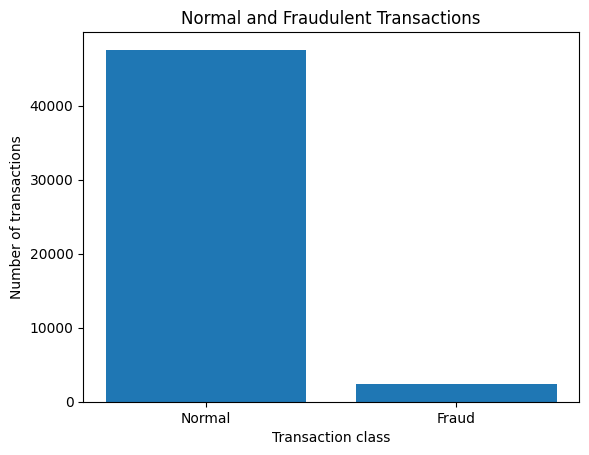

In [34]:
# Compare the number of normal and fraudulent transactions

fraud_counts = fraud_data['Fraud_Label'].value_counts().sort_index()

plt.bar(['Normal', 'Fraud'], fraud_counts.values)
plt.xlabel('Transaction class')
plt.ylabel('Number of transactions')
plt.title('Normal and Fraudulent Transactions')
plt.show()

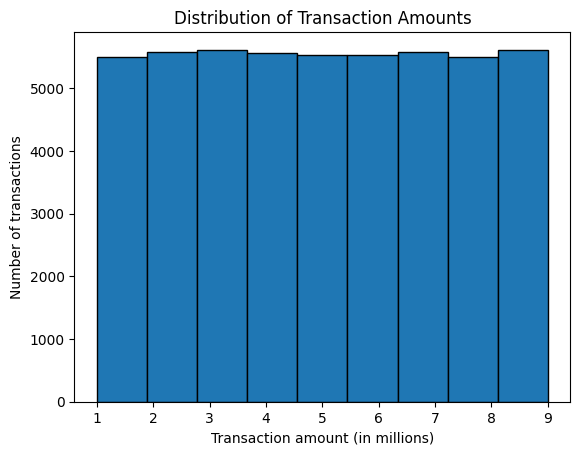

In [35]:
# Show the distribution of transaction amounts

plt.hist(
    fraud_data['Transaction_Amount (in Million)'].dropna(),
    bins=9,
    edgecolor='black'
)
plt.xlabel('Transaction amount (in millions)')
plt.ylabel('Number of transactions')
plt.title('Distribution of Transaction Amounts')
plt.show()

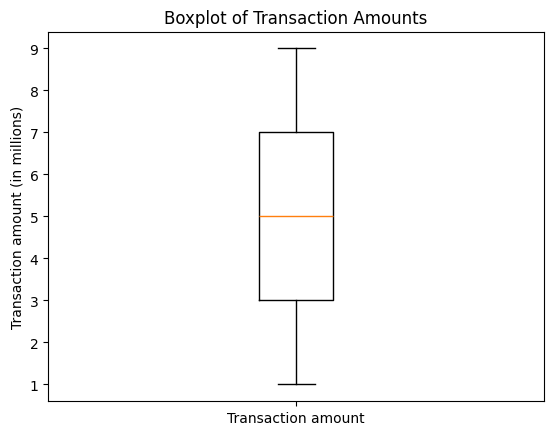

In [36]:
# Show the median, spread and potential outliers in transaction amounts

plt.boxplot(
    fraud_data['Transaction_Amount (in Million)'].dropna()
)
plt.xticks([1], ['Transaction amount'])
plt.ylabel('Transaction amount (in millions)')
plt.title('Boxplot of Transaction Amounts')
plt.show()

The bar chart shows that normal transactions greatly outnumber fraudulent transactions. From the histogram, we can see that transaction amounts are roughly evenly distributed between 1 and 9 million. The boxplot shows a median of 5 million, with the middle 50% of values between 3 and 7 million. No transaction amounts were flagged as outliers using the default 1.5×IQR rule. However, this does not mean there are no fraudulent transactions, as an unusual amount alone does not determine whether a transaction is fraud.


### 4.5 Relationships and Unusual Patterns

Transaction_Amount (in Million)
1.0    4.923692
2.0    4.853152
3.0    4.880656
4.0    4.948713
5.0    4.740365
6.0    4.664618
7.0    5.062837
8.0    4.569452
9.0    4.981253
Name: Fraud_Label, dtype: float64


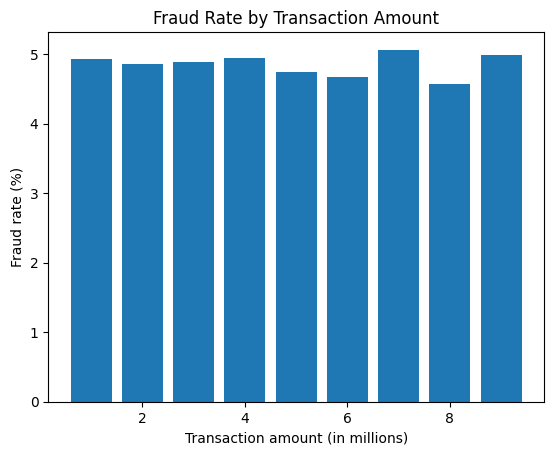

In [37]:
# Compare fraud rates across transaction amounts

amount_fraud_rate = (
    fraud_data.groupby('Transaction_Amount (in Million)')['Fraud_Label']
    .mean() * 100
)

print(amount_fraud_rate)

plt.bar(amount_fraud_rate.index, amount_fraud_rate.values)
plt.xlabel('Transaction amount (in millions)')
plt.ylabel('Fraud rate (%)')
plt.title('Fraud Rate by Transaction Amount')
plt.show()